# The Full Pipeline of Linear Regression

https://claude.ai/public/artifacts/e09269b1-ab95-44af-a03a-f6daea4e5ca1

#### 1. Import Required libraries


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#### 2. Load Data

In [4]:
df = pd.read_csv("score.csv")
df.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


In [6]:
print(f"Dataset shape: {df.shape}")

Dataset shape: (25, 2)


In [7]:
a = len(df)
a

25

#### 2. Collect Labelled Data

In [9]:
# hours is 1D array, make it as 2D array for better input model training,
# linear regression model takes only 2D values
# scores is output feature , so need to make it as 2D array

hours = df[['Hours']].values 
scores = df['Scores'].values


In [11]:
print(f"Hours shape : {hours.shape}") #hours is 2D array now
print(f"Scores shape : {scores.shape}")


Hours shape : (25, 1)
Scores shape : (25,)


#### 3.  Split the data into training and testing sets

In [14]:
hours_train, hours_test, scores_train, scores_test = train_test_split(
                                                        hours, scores, test_size = 0.2, random_state=42
)

In [15]:
print(f'hours_train : {hours_train.shape}')
print(f'hours_test : {hours_test.shape}')

print(f'scores_train : {scores_train.shape}')
print(f'scores_test : {scores_test.shape}')

hours_train : (20, 1)
hours_test : (5, 1)
scores_train : (20,)
scores_test : (5,)


#### 4. Choose Model

In [16]:
model = LinearRegression()

#### 5. Train Model

In [17]:
model.fit(hours_train, scores_train)
print(f"{model} 🧜‍♂️ Model Trained Successfully")

LinearRegression() 🧜‍♂️ Model Trained Successfully


#### 6. Model Parameters

In [18]:
slope = model.coef_[0]
intercept = model.intercept_

print(f"Equation : Score = {slope:.4f} *  Hours + {intercept:.4f}")
print(f"Slope (coefficient) : {slope:.4f}")
print(f"Intercept : {intercept:.4f}")

Equation : Score = 9.6821 *  Hours + 2.8269
Slope (coefficient) : 9.6821
Intercept : 2.8269


#### 7. Model Predictions

In [21]:
# Before making predictions, reshape it to 2D array:
hours_train = hours_train.reshape(-1, 1)
hours_test = hours_test.reshape(-1, 1)

# Now predict:
scores_train_pred = model.predict(hours_train)
scores_test_pred = model.predict(hours_test)

#### 8. Evaluate Model
##### Training Set

In [22]:
train_r2 = r2_score(scores_train, scores_train_pred)
train_rmse = np.sqrt(mean_squared_error(scores_train, scores_train_pred))
train_mae = mean_absolute_error(scores_train, scores_train_pred)

print("Training Set Performance")
print(f"R^2: {train_r2:.4f}")
print(f"RMSE: {train_rmse:.4f}")
print(f"MAE: {train_mae:.4f}")

Training Set Performance
R^2: 0.9491
RMSE: 5.6085
MAE: 5.2214


##### Testing Set

In [23]:
test_r2 = r2_score(scores_test, scores_test_pred)
test_rmse = np.sqrt(mean_squared_error(scores_test, scores_test_pred))
test_mae = mean_absolute_error(scores_test, scores_test_pred)

print("Testing Set Performance")
print(f"R^2: {test_r2:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAE: {test_mae:.4f}")

Testing Set Performance
R^2: 0.9678
RMSE: 4.3524
MAE: 3.9208


#### 9. Visualize Results

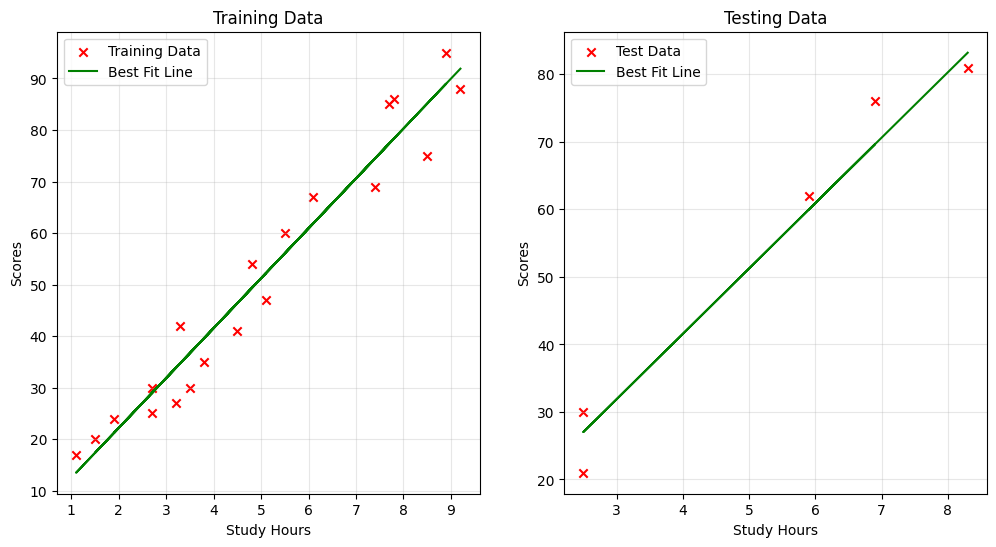

In [24]:
plt.figure(figsize=(12,6))

# plot1 : Training Data
plt.subplot(1,2,1)
plt.scatter(hours_train, scores_train, c='red', marker='x', label="Training Data")
plt.plot(hours_train, scores_train_pred, c='g', label="Best Fit Line")
plt.xlabel("Study Hours")
plt.ylabel("Scores")
plt.title("Training Data")
plt.grid(True, alpha=0.3)
plt.legend()


# plot2 : Test Data
plt.subplot(1,2,2)
plt.scatter(hours_test, scores_test, c='r', marker='x', label="Test Data")
plt.plot(hours_test, scores_test_pred, c='g', label="Best Fit Line")
plt.xlabel("Study Hours")
plt.ylabel("Scores")
plt.title("Testing Data")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


#### 10. Predict Function

In [25]:
def predict_score(hours):
    prediction = model.predict([[hours]])[0]
    return prediction

In [26]:
test_hours = [2, 5, 10, 15]
for hours in test_hours:
    score = predict_score(hours)
    print(f"Hours: {hours} -> Predicted Score: {score}")

Hours: 2 -> Predicted Score: 22.19104866281113
Hours: 5 -> Predicted Score: 51.23728312617822
Hours: 10 -> Predicted Score: 99.6476738984567
Hours: 15 -> Predicted Score: 148.05806467073518


#### 11. Save Model

In [145]:
plt.tight_layout()
plt.savefig('regression_results.png', dpi=300, bbox_inches='tight')
print("Visualization saved as 'regression_results.png'")
plt.show()

Visualization saved as 'regression_results.png'


<Figure size 640x480 with 0 Axes>

#### 12. Residual Analysis

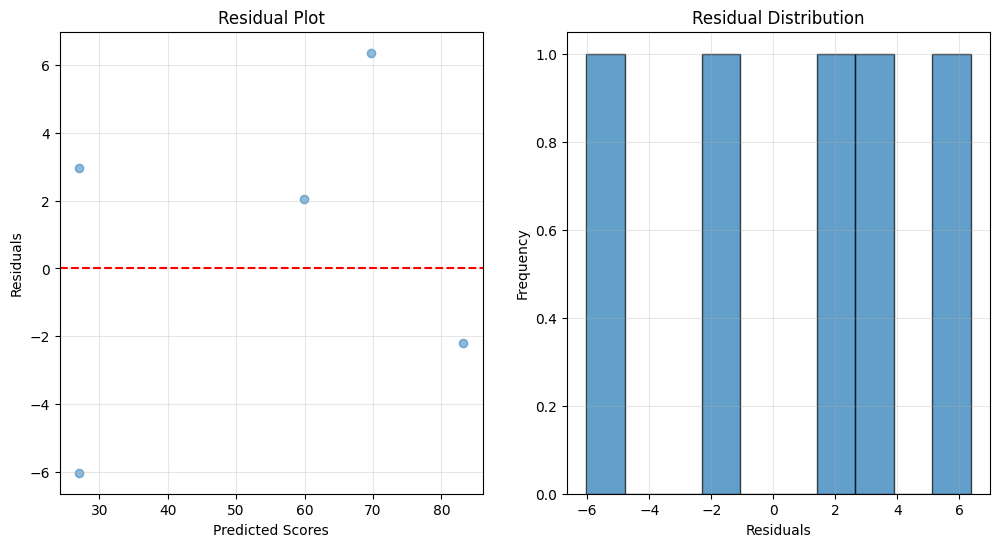

In [30]:
residuals = scores_test - scores_test_pred
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.scatter(scores_test_pred, residuals, alpha = 0.5)
plt.axhline(y=0, c='r', linestyle = '--')
plt.xlabel("Predicted Scores")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True, alpha=0.3)


plt.subplot(1,2,2)
plt.hist(residuals, bins =10, edgecolor = 'black', alpha = 0.7)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title("Residual Distribution")
plt.grid(True, alpha=0.3)

plt.show()

In [31]:
plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=300, bbox_inches='tight')
print("Residual analysis saved as 'residual_analysis.png'")

Residual analysis saved as 'residual_analysis.png'


<Figure size 640x480 with 0 Axes>

In [151]:
print("\n=== Training Complete! ===")
print(f"Final Model: Score = {intercept:.4f} + {slope:.4f} × Hours")
print(f"Test R² Score: {test_r2:.4f}")


=== Training Complete! ===
Final Model: Score = 2.8269 + 9.6821 × Hours
Test R² Score: 0.9678


https://claude.ai/public/artifacts/e09269b1-ab95-44af-a03a-f6daea4e5ca1